# Dark Photon FIRAS Constraints

Computes FIRAS 95% CL upper limits on the kinetic mixing parameter $\epsilon$
as a function of dark photon mass $m_{\gamma'}$ using profile likelihood
with floating blackbody temperature, following Arsenadze et al. (2025).

Methods compared:
1. **Photon GF convolution** (floating $T$): Analytic photon injection Green's function
   convolved with broadband depletion source
2. **PDE spectral fit** (floating $T$, publication): Full PDE solver NC-stripped template

Uses the **full 43×43 FIRAS covariance matrix** from the LAMBDA archive.

### References

- Chluba (2015), MNRAS 454, 4182. [arXiv:1506.06582](https://arxiv.org/abs/1506.06582)
- Chluba, Cyr & Johnson (2024), MNRAS 535(2), 1874. [arXiv:2409.12115](https://arxiv.org/abs/2409.12115)
- Arsenadze, Caputo, Gan, Liu & Ruderman (2025), JHEP 03, 018. [arXiv:2409.12940](https://arxiv.org/abs/2409.12940)
- Fixsen et al. (1996), ApJ 473, 576.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from spectroxide import (
    greens_function, run_sweep,
    mu_shape, y_shape, g_bb, planck,
    j_mu, j_y, j_bb, j_bb_star,
    visibility_j_compton,
    KAPPA_C, G3_PLANCK, G2_PLANCK,
    DEFAULT_COSMO, PLANCK2015_COSMO, PLANCK2018_COSMO,
    delta_n_to_delta_I, decompose_distortion,
    ionization_fraction,
    apply_style,
    load_or_build_greens_table, GreensTable,
)
from spectroxide.firas import FIRASData
from spectroxide.greens import (
    _cosmo_hubble, _cosmo_n_e, _cosmo_omega_gamma,
    _C_LIGHT, _K_BOLTZMANN, _HBAR,
)
from spectroxide.plot_params import (
    C, DOUBLE_COL, SINGLE_COL, LW, LW_THICK, LW_THIN,
    LABEL_SIZE, LEGEND_SIZE, ANNOT_SIZE,
)

# Constants
ALPHA_FS = 7.297_352_5693e-3
M_ELECTRON = 9.109_383_7015e-31  # kg
EV_IN_JOULES = 1.602_176_634e-19
HBAR_EV_S = _HBAR / EV_IN_JOULES
G1_PLANCK = np.pi**2 / 6.0

apply_style()
results = []
cosmo = DEFAULT_COSMO


## 1. Plasma Frequency and Resonance Redshift Mapping

The resonance condition is $m_{\gamma'} = \omega_{\rm pl}(z_{\rm res})$ where
$\omega_{\rm pl}^2 = 4\pi\alpha n_e / m_e$.
This maps dark photon mass to a specific redshift, and hence a specific distortion era.

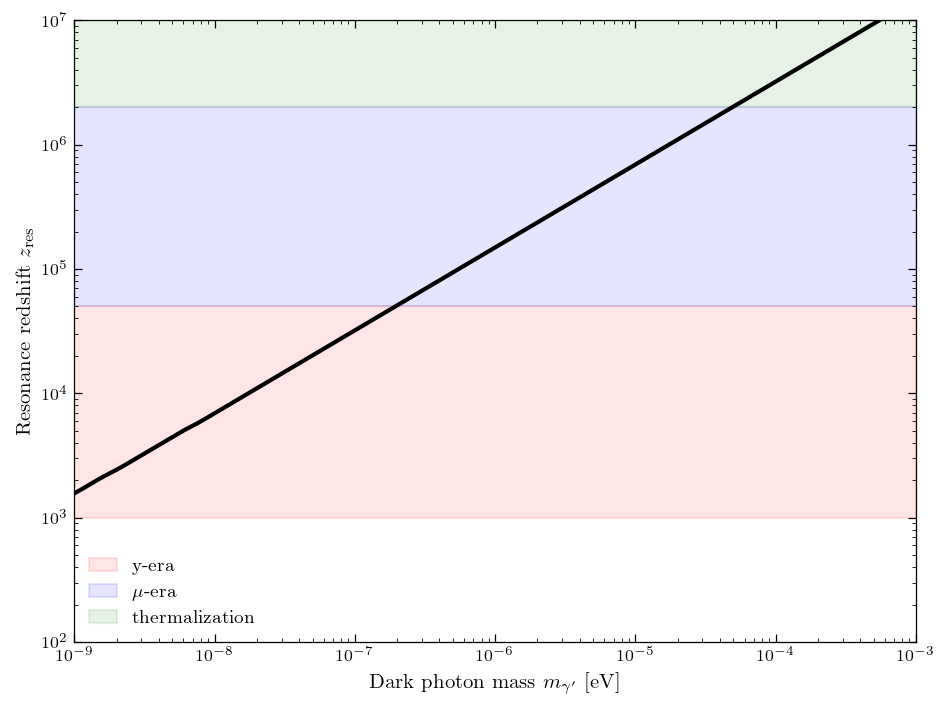

    m [eV]       z_res           Era    Pass
---------------------------------------------
   3.0e-08       14386         y-era    PASS
   1.0e-06      149010    transition    PASS
   1.0e-05      691648        mu-era    PASS
   3.0e-05     1438686       deep mu    PASS


In [8]:
def plasma_frequency_ev(z, cosmo=DEFAULT_COSMO):
    """Photon plasma frequency [eV] at redshift z."""
    n_e = _cosmo_n_e(z, cosmo)
    omega_pl_sq = 4 * np.pi * ALPHA_FS * _HBAR * _C_LIGHT * n_e / M_ELECTRON
    return HBAR_EV_S * np.sqrt(omega_pl_sq)

def resonance_redshift(m_dp_ev, cosmo=DEFAULT_COSMO, z_min=10, z_max=3e7):
    """Find z_res where omega_pl(z_res) = m_dp using bisection."""
    def f(z):
        return plasma_frequency_ev(z, cosmo) - m_dp_ev
    if f(z_min) * f(z_max) > 0:
        return None
    return brentq(f, z_min, z_max)

# Map mass range to resonance redshifts
masses_ev = np.logspace(-9, -3, 200)
z_res_arr = np.array([resonance_redshift(m) or np.nan for m in masses_ev])

fig, ax = plt.subplots()
valid = np.isfinite(z_res_arr)
ax.loglog(masses_ev[valid], z_res_arr[valid], 'k-', lw=2)
ax.axhspan(1e3, 5e4, alpha=0.1, color='r', label='y-era')
ax.axhspan(5e4, 2e6, alpha=0.1, color='b', label=r'$\mu$-era')
ax.axhspan(2e6, 1e7, alpha=0.1, color='g', label='thermalization')
ax.set_xlabel(r'Dark photon mass $m_{\gamma^{\prime}}$ [eV]')
ax.set_ylabel(r'Resonance redshift $z_{\rm res}$')
ax.legend(fontsize=9)
ax.set_xlim(1e-9, 1e-3)
ax.set_ylim(100, 1e7)
plt.tight_layout()
plt.savefig('../figures/dp_mass_vs_zres.pdf')
plt.show()

# Verify key mass-era mappings
test_masses = [
    (3e-8, 'y-era',      lambda z: z < 5e4),
    (1e-6, 'transition',  lambda z: 3e4 < z < 3e5),
    (1e-5, 'mu-era',     lambda z: 1e5 < z < 2e6),
    (3e-5, 'deep mu',    lambda z: z > 5e5),
]
print(f"{'m [eV]':>10s}  {'z_res':>10s}  {'Era':>12s}  {'Pass':>6s}")
print("-" * 45)
for m, era_name, check in test_masses:
    zr = resonance_redshift(m)
    ok = zr is not None and check(zr)
    print(f"{m:10.1e}  {zr:10.0f}  {era_name:>12s}  {'PASS' if ok else 'FAIL':>6s}")
    results.append((f"z_res({m:.0e}) in {era_name}", ok, f"z_res={zr:.0f}" if zr else "None"))

In [20]:
resonance_redshift(0.2e-8)

2429.6560977270055

## 2. Spectral Integrals and $\gamma_{\rm con}$

Conversion parameter from Chluba & Cyr (2024) Eq. 6:
$$\gamma_{\rm con}(\epsilon, m_{\gamma'}) = \frac{\pi \epsilon^2 m_{\gamma'}^2}{\left|\frac{d\ln\omega_{\rm pl}^2}{d\ln(1+z)}\right|_{z_{\rm res}} T_{\rm CMB}(z_{\rm res})\, H(z_{\rm res})}$$

In [9]:
# Spectral integrals
g1 = G1_PLANCK  # pi^2/6
g2 = G2_PLANCK  # 2*zeta(3)
g3 = G3_PLANCK  # pi^4/15
kappa_c = KAPPA_C

ratio_g2_g3 = g2 / g3
ratio_g1_g2 = g1 / g2
three_over_kappa = 3.0 / kappa_c

# Entropy-corrected mu coefficient (Chluba & Cyr Eq. 9)
entropy_factor = -ratio_g2_g3 + (4.0/3.0) * ratio_g1_g2
mu_coeff_corrected = three_over_kappa * entropy_factor
mu_coeff_energy_only = three_over_kappa * ratio_g2_g3

print(f"G_2/G_3 = {ratio_g2_g3:.4f}  (target: 0.3702)")
print(f"G_1/G_2 = {ratio_g1_g2:.4f}  (target: 0.6842)")
print(f"3/kappa = {three_over_kappa:.4f}  (target: 1.4007)")
print(f"mu coeff (entropy-corrected): {mu_coeff_corrected:.4f}  (target: +0.7593)")
print(f"mu coeff (energy-only):       {mu_coeff_energy_only:.4f}  (target: 0.5185)")
print(f"Sign reversal: corrected is POSITIVE, energy-only would give NEGATIVE mu")

results.append(("G2/G3 = 0.3702", abs(ratio_g2_g3 - 0.3702) / 0.3702 < 0.01, f"{ratio_g2_g3:.4f}"))
results.append(("G1/G2 = 0.6842", abs(ratio_g1_g2 - 0.6842) / 0.6842 < 0.01, f"{ratio_g1_g2:.4f}"))
results.append(("mu_corr coeff ~ 0.76", abs(mu_coeff_corrected - 0.7593) / 0.7593 < 0.01,
                f"{mu_coeff_corrected:.4f}"))

G_2/G_3 = 0.3702  (target: 0.3702)
G_1/G_2 = 0.6842  (target: 0.6842)
3/kappa = 1.4007  (target: 1.4007)
mu coeff (entropy-corrected): 0.7593  (target: +0.7593)
mu coeff (energy-only):       0.5185  (target: 0.5185)
Sign reversal: corrected is POSITIVE, energy-only would give NEGATIVE mu


In [10]:
def dln_omega_pl2_dlna(z, cosmo=DEFAULT_COSMO):
    """Numerical |d ln omega_pl^2 / d ln(1+z)| at redshift z.
    
    omega_pl^2 propto X_e(z) * (1+z)^3, so
    d ln omega_pl^2 / d ln(1+z) = (1+z) * d ln X_e/dz + 3.
    """
    dz = max(0.1, z * 1e-4)
    xe_p = ionization_fraction(z + dz, cosmo)
    xe_m = ionization_fraction(z - dz, cosmo)
    xe = ionization_fraction(z, cosmo)
    dlnxe_dz = (xe_p - xe_m) / (2 * dz * xe) if xe > 1e-30 else 0.0
    return abs((1.0 + z) * dlnxe_dz + 3.0)


def gamma_con(epsilon, m_ev, cosmo=DEFAULT_COSMO):
    """Compute gamma_con from Chluba & Cyr (2024) Eq. 6."""
    z_res = resonance_redshift(m_ev, cosmo)
    if z_res is None:
        return None, None
    T_cmb_ev = _K_BOLTZMANN * cosmo["t_cmb"] * (1 + z_res) / EV_IN_JOULES
    H_ev = HBAR_EV_S * _cosmo_hubble(z_res, cosmo)
    dlna = dln_omega_pl2_dlna(z_res, cosmo)
    gc = np.pi * epsilon**2 * m_ev**2 / (dlna * T_cmb_ev * H_ev)
    return gc, z_res


def gc_per_eps2(m_ev, z_res, cosmo=DEFAULT_COSMO):
    """gamma_con / epsilon^2 at resonance redshift."""
    T_cmb_ev = _K_BOLTZMANN * cosmo["t_cmb"] * (1 + z_res) / EV_IN_JOULES
    H_ev = HBAR_EV_S * _cosmo_hubble(z_res, cosmo)
    dlna = dln_omega_pl2_dlna(z_res, cosmo)
    return np.pi * m_ev**2 / (dlna * T_cmb_ev * H_ev)


# Verify epsilon^2 scaling
gc1, _ = gamma_con(1e-6, 1e-5)
gc2, _ = gamma_con(2e-6, 1e-5)
ratio = gc2 / gc1
print(f"gamma_con scaling with epsilon^2: ratio = {ratio:.4f} (expected 4.0)")
results.append(("gamma_con ~ eps^2", abs(ratio - 4.0) < 0.01, f"ratio={ratio:.4f}"))

# Recombination correction
print(f"\nPlasma mass derivative correction (|d ln omega_pl^2/d ln a| / 3):")
for m in [1e-11, 1e-10, 3e-10, 1e-9, 1e-7, 1e-5]:
    zr = resonance_redshift(m)
    if zr is not None:
        dlna = dln_omega_pl2_dlna(zr)
        regime = 'post-recomb' if zr < 1100 else 'pre-recomb'
        print(f"  m={m:.0e}: z_res={zr:.0f} ({regime}), |d ln w^2/d ln a| = {dlna:.2f} (naive = 3)")

gamma_con scaling with epsilon^2: ratio = 4.0000 (expected 4.0)

Plasma mass derivative correction (|d ln omega_pl^2/d ln a| / 3):
  m=1e-11: z_res=669 (post-recomb), |d ln w^2/d ln a| = 6.51 (naive = 3)
  m=1e-10: z_res=987 (post-recomb), |d ln w^2/d ln a| = 15.69 (naive = 3)
  m=3e-10: z_res=1152 (pre-recomb), |d ln w^2/d ln a| = 12.33 (naive = 3)
  m=1e-09: z_res=1569 (pre-recomb), |d ln w^2/d ln a| = 3.37 (naive = 3)
  m=1e-07: z_res=32102 (pre-recomb), |d ln w^2/d ln a| = 3.00 (naive = 3)
  m=1e-05: z_res=691648 (pre-recomb), |d ln w^2/d ln a| = 3.00 (naive = 3)


## 3. FIRAS Data and Fit Infrastructure

Load FIRAS monopole residuals and the **full 43×43 covariance matrix** from the
LAMBDA archive (Fixsen et al. 1996). The covariance is constructed as
$C_{ij} = \sigma_i\,\sigma_j\,\mathrm{corr}_{ij}$, where $\sigma_i$ are the published
monopole 1$\sigma$ errors and the correlation matrix comes from
`FIRAS_COVARIANCE_MATRIX_LOWF.FITS`.

Profile likelihood uses the Arsenadze et al. (2025) method: the blackbody temperature $T$
is floated as a free parameter, and the signal amplitude is profiled analytically at each
trial $T$. The residuals $I_{\rm obs}(\nu) - B(\nu, T)$ and the template
$\mathcal{T}(h\nu/kT)$ are both recomputed at each trial temperature.


In [11]:
# Load FIRAS data with full covariance matrix
firas = FIRASData()
print(firas)

# Convenience aliases matching the rest of the notebook
x_firas = firas.x
nu_GHz_firas = firas.freq_ghz
residual_kJy = firas.residual_kJy
sigma_kJy = firas.sigma_kJy

# Convert residuals and sigma to Delta_n units for legacy compatibility
h_planck = 6.62607015e-34
k_B = 1.380649e-23
c_light = 2.99792458e8
T_CMB = 2.726

nu_Hz = firas.freq_cm * 100 * c_light
conversion = 2 * h_planck * nu_Hz**3 / c_light**2  # W/m^2/Hz/sr per unit Delta_n
sigma_dn = (sigma_kJy * 1e-23) / conversion
residual_dn = (residual_kJy * 1e-23) / conversion

# Precompute FIRAS-sampled basis functions
gbb_firas = g_bb(x_firas)
npl_firas = planck(x_firas)

# Build inverse covariance in Delta_n units: C_dn = C_kJy / (conv * conv)
# where conv_i converts Delta_n_i to kJy/sr at channel i
conv_vec = conversion * 1e23  # Delta_n -> kJy/sr
cov_dn = firas.cov / np.outer(conv_vec, conv_vec)  # (kJy/sr)^2 / (kJy/sr per dn)^2 = dn^2
cov_inv_dn = np.linalg.inv(cov_dn)

print(f'FIRAS: {len(x_firas)} channels, nu = {nu_GHz_firas[0]:.0f}--{nu_GHz_firas[-1]:.0f} GHz')
print(f'x_firas = {x_firas[0]:.2f}--{x_firas[-1]:.2f}')
print(f'Covariance matrix condition number: {np.linalg.cond(cov_dn):.1e}')


def firas_profile_limit_floating_T(template_dn_func):
    """Profile likelihood 95% CL upper limit on amplitude, floating T.

    Uses FIRASData.profile_limit_floating_T: for each trial T, recomputes
    residuals as I_obs - B(nu, T) and evaluates the template at x(T) = hnu/(kT).
    The amplitude is analytically profiled; T is numerically optimised.

    Following Arsenadze et al. (2025).
    """
    result = firas.profile_limit_floating_T(
        template_dn_func, cl=0.95, one_sided=True,
    )
    return result['upper_limit'], result['amplitude'], result['sigma'], result['t_best']


def firas_profile_limit_gbb(template_per_gc):
    """Profile likelihood 95% CL upper limit on gamma_con (G_bb nuisance, fixed T).

    Legacy method: fits FIRAS residuals d = gc * template + alpha * G_bb.
    Profiles over alpha (T shift nuisance), one-sided.
    Uses full covariance matrix.
    """
    A = np.column_stack([template_per_gc, gbb_firas])
    F = A.T @ cov_inv_dn @ A
    F_inv = np.linalg.inv(F)
    theta_hat = F_inv @ (A.T @ cov_inv_dn @ residual_dn)
    gc_hat = theta_hat[0]
    sigma_gc = np.sqrt(F_inv[0, 0])
    gc_95 = max(gc_hat + 1.645 * sigma_gc, 0.0)
    return gc_95, gc_hat, sigma_gc


# Verify: floating-T on pure mu template should match standard limit
mu_limit_gbb = firas.upper_limit_mu(cl=0.95, marginalise_y=False)
mu_result_T = firas.profile_limit_floating_T(mu_shape, cl=0.95)
print(f'\nmu limit (G_bb nuisance, fixed T):  |mu| < {mu_limit_gbb:.2e}')
print(f'mu limit (floating T, Arsenadze):    |mu| < {mu_result_T["upper_limit"]:.2e}')
print(f'  T_best = {mu_result_T["t_best"]:.6f} K')
diff_pct = abs(mu_limit_gbb - mu_result_T['upper_limit']) / mu_limit_gbb * 100
print(f'  Difference: {diff_pct:.2f}%')


FIRASData(n_freq=43, freq_range=[68.1, 639.5] GHz, x_range=[1.20, 11.26])
FIRAS: 43 channels, nu = 68--639 GHz
x_firas = 1.20--11.26
Covariance matrix condition number: 6.3e+05

mu limit (G_bb nuisance, fixed T):  |mu| < 7.70e-05
mu limit (floating T, Arsenadze):    |mu| < 4.25e-05
  T_best = 2.725024 K
  Difference: 44.80%


## 4. FIRAS Constraints: GF and PDE

All methods use the **full 43x43 FIRAS covariance matrix** and the **Arsenadze et al. (2025)
floating-T profile likelihood** (blackbody temperature floated, amplitude profiled analytically).

### Case 1: Photon GF convolution

Convolves the analytic photon injection Green's function (Chluba 2015, Arsenadze et al. 2025)
with the broadband dark photon depletion source at $z_{\rm res}$:
$$\Delta n(x) = \int G_{\rm photon}(x, x', z_{\rm res}) \times \left[-p(x')\,n_{\rm pl}(x')\,\frac{x'^2}{G_2}\right] dx'$$
Also computes the custom 3-component formula (`distortion_from_dark_photon`) for comparison.

### Case 2: PDE spectral fit (publication)

Template from full PDE solver with IC depletion, post-hoc NC-stripped.
This is the most accurate method and is used for the publication figure.


In [12]:
# === Dark photon templates ===
from spectroxide import distortion_from_dark_photon, greens_function_photon

def dp_gf_custom_template(x_obs, z_res):
    """Dark photon template per gamma_con via custom 3-component GF."""
    return distortion_from_dark_photon(x_obs, 1.0, z_res)


def dp_gf_photon_template(x_obs, z_res, n_xprime=500):
    """Dark photon template per gamma_con via photon GF convolution.

    Convolves the analytic photon GF G_photon(x, x', z_res) with the
    broadband depletion source at the resonance redshift:
        dn(x) = int G_photon(x, x', z_res) * source(x') dx'
    where source(x') = -(1/x') * n_pl(x') * x'^2 / G2 per unit gamma_con
    (small-gamma limit: p(x') ~ gamma_con/x').
    """
    x_obs = np.atleast_1d(np.asarray(x_obs, dtype=np.float64))
    x_prime = np.linspace(0.05, 30, n_xprime)
    dx = x_prime[1] - x_prime[0]
    npl = planck(x_prime)
    # Source per unit gamma_con in small-gc limit: p(x') ~ gc/x'
    # d(DN/N) = -(1/x') * n_pl * x'^2 / G2 * dx' = -x' * n_pl / G2 * dx'
    source_per_gc = -x_prime * npl / G2_PLANCK

    dn = np.zeros_like(x_obs)
    for i, xp in enumerate(x_prime):
        if abs(source_per_gc[i]) < 1e-30:
            continue
        g = greens_function_photon(x_obs, xp, z_res, number_conserving=True)
        dn += g * source_per_gc[i] * dx
    return dn


# === Case 1: Photon GF convolution with floating-T profile likelihood ===
masses_firas = np.logspace(-11, -3.5, 300)
eps_limit_gf = np.full_like(masses_firas, np.nan)
eps_limit_gf_custom = np.full_like(masses_firas, np.nan)  # custom formula for comparison
z_res_gf = np.full_like(masses_firas, np.nan)
t_best_gf = np.full_like(masses_firas, np.nan)

for i, m in enumerate(masses_firas):
    zr = resonance_redshift(m)
    if zr is None:
        continue
    z_res_gf[i] = zr
    gpe2 = gc_per_eps2(m, zr)

    # Photon GF convolution
    template_func = lambda x, _zr=zr: dp_gf_photon_template(x, _zr)
    try:
        gc_95, gc_hat, sigma_gc, T_best = firas_profile_limit_floating_T(template_func)
    except (np.linalg.LinAlgError, ValueError):
        continue
    if gc_95 > 0 and gpe2 > 0:
        eps_limit_gf[i] = np.sqrt(gc_95 / gpe2)
        t_best_gf[i] = T_best

    # Custom 3-component formula (for comparison)
    template_custom = lambda x, _zr=zr: distortion_from_dark_photon(x, 1.0, _zr)
    try:
        gc_95_c, _, _, _ = firas_profile_limit_floating_T(template_custom)
    except (np.linalg.LinAlgError, ValueError):
        continue
    if gc_95_c > 0 and gpe2 > 0:
        eps_limit_gf_custom[i] = np.sqrt(gc_95_c / gpe2)

valid_gf = np.isfinite(eps_limit_gf)
valid_gf_custom = np.isfinite(eps_limit_gf_custom)
print(f'Photon GF convolution: {np.sum(valid_gf)} masses with valid limits')
print(f'Custom 3-component GF: {np.sum(valid_gf_custom)} masses with valid limits')

# Compare
both_valid = valid_gf & valid_gf_custom
if np.any(both_valid):
    diff = np.abs(eps_limit_gf[both_valid] - eps_limit_gf_custom[both_valid]) / eps_limit_gf_custom[both_valid]
    print(f'Photon GF conv vs custom: max diff = {np.max(diff)*100:.1f}%, median = {np.median(diff)*100:.1f}%')


/tmp/ipykernel_14006/4272143530.py:30: UserWarning: z_h=669: Low-redshift injection (z < 5000). J_Compton < 0.01 here: Comptonization is highly inefficient, so heat injection produces negligible mu/y distortions. Use greens_function_with_cosmo or the cosmo-aware run_single (from spectroxide import greens_function_with_cosmo, run_single) for physically correct results; the basic Green's function overestimates y by orders of magnitude in this regime.
  g = greens_function_photon(x_obs, xp, z_res, number_conserving=True)


KeyboardInterrupt: 

In [13]:
# === Case 2: PDE spectral fit (floating-T profile likelihood, parallelized) ===
from concurrent.futures import ThreadPoolExecutor, as_completed


def strip_gbb_nc(x, delta_n):
    """Number-conserving G_bb subtraction: int x^2 Dn_stripped dx = 0."""
    gbb = g_bb(x)
    alpha = np.trapz(x**2 * delta_n, x) / np.trapz(x**2 * gbb, x)
    return delta_n - alpha * gbb, alpha


def run_dp_pde(epsilon, m_ev, npts):
    """Run PDE with dark photon resonance injection (modern API).
    Returns raw (un-stripped) x, delta_n.
    Solver auto-sets z_start=z_res and auto-enables NC for depletion.
    """
    result = run_sweep(
        injection={'type': 'dark_photon_resonance',
                   'epsilon': epsilon, 'm_ev': m_ev},
        z_end=100,
        n_points=npts,
        timeout=1200,
    )
    r = result['results'][0] if isinstance(result['results'], list) else result['results']
    x = np.array(r['x'])
    dn = np.array(r['delta_n'])
    return x, dn


def _pde_worker(m_dp, eps_ref, firas_obj):
    """Run one PDE mass point and return FIRAS limit (floating-T method)."""
    zr = resonance_redshift(m_dp)
    if zr is None:
        return m_dp, None, None, None, None

    gpe2 = gc_per_eps2(m_dp, zr)
    gc_ref = gpe2 * eps_ref**2

    if zr < 5e4:
        npts = 2000
    elif zr < 1e6:
        npts = 4000
    else:
        npts = 8000

    try:
        x_pde, dn_pde = run_dp_pde(eps_ref, m_dp, npts)
        dn_nc, _ = strip_gbb_nc(x_pde, dn_pde)

        # Build interpolated template function (Δn per unit gc)
        dn_per_gc_arr = dn_nc / gc_ref
        def template_func(x, _x_pde=x_pde, _dn=dn_per_gc_arr):
            return np.interp(x, _x_pde, _dn)

        # Floating-T profile likelihood
        result = firas_obj.profile_limit_floating_T(
            template_func, cl=0.95, one_sided=True,
        )
        gc_95 = result['upper_limit']
        T_best = result['t_best']

        eps_lim = np.sqrt(gc_95 / gpe2) if gc_95 > 0 and gpe2 > 0 else np.inf
        return m_dp, zr, eps_lim, x_pde, dn_per_gc_arr
    except Exception as e:
        return m_dp, zr, None, None, str(e)


In [ ]:
# PDE mass grid: denser overall, extra points in 1e-4 to 2e-4 range
masses_low = np.geomspace(1e-12, 8e-5, 30)
masses_high = np.geomspace(1e-4, 2e-4, 10)
masses_pde = np.unique(np.concatenate([masses_low, masses_high]))
eps_ref = 1e-8

print(f'Launching {len(masses_pde)} PDE runs in parallel...')

# Run in parallel using ThreadPoolExecutor (each run_sweep spawns a subprocess)
pde_raw_results = {}
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {
        executor.submit(_pde_worker, m, eps_ref, firas): m
        for m in masses_pde
    }
    for future in as_completed(futures):
        m_dp, zr, eps_lim, x_pde, dn_per_gc = future.result()
        regime = ('post-recomb' if zr < 1100 else 'pre-recomb') if zr else '???'
        if eps_lim is not None and not isinstance(dn_per_gc, str):
            pde_raw_results[m_dp] = {
                'z_res': zr, 'eps_lim': eps_lim,
                'x': x_pde, 'dn_per_gc': dn_per_gc,
            }
            print(f'  m={m_dp:.2e} eV, z_res={zr:.0f} ({regime}) -> eps_95={eps_lim:.2e}')
        elif isinstance(dn_per_gc, str):
            print(f'  m={m_dp:.2e} eV, z_res={zr:.0f} ({regime}) FAILED: {dn_per_gc}')
        else:
            print(f'  m={m_dp:.2e} eV: no resonance, skipping')

# Sort by mass for plotting
masses_pde_valid = np.array(sorted(pde_raw_results.keys()))
eps_pde = np.array([pde_raw_results[m]['eps_lim'] for m in masses_pde_valid])
pde_results = {m: pde_raw_results[m] for m in masses_pde_valid}

print(f'\nCompleted {len(pde_results)}/{len(masses_pde)} PDE runs')

# Compare PDE vs GF (both floating-T)
print(f'\n{"m [eV]":>10s}  {"z_res":>8s}  {"eps PDE":>10s}  {"eps GF":>10s}  {"diff":>8s}')
print('-' * 55)
max_diff_pre = 0
for m_dp in masses_pde_valid:
    e_pde = pde_raw_results[m_dp]['eps_lim']
    zr = pde_raw_results[m_dp]['z_res']

    # Find nearest GF limit
    idx = np.argmin(np.abs(masses_firas - m_dp))
    e_gf = eps_limit_gf[idx] if valid_gf[idx] else np.nan

    diff = (e_pde - e_gf) / e_gf * 100 if np.isfinite(e_gf) and e_gf > 0 else np.nan
    if zr > 1100 and zr < 4e6 and np.isfinite(diff):
        max_diff_pre = max(max_diff_pre, abs(diff))
    print(f'{m_dp:10.2e}  {zr:8.0f}  {e_pde:10.3e}  {e_gf:10.3e}  {diff:+7.1f}%')

results.append(('PDE vs GF spec-limit (<10%)', max_diff_pre < 10.0,
    f'max diff {max_diff_pre:.1f}% over pre-recomb z<4e6 masses'))

# Save results so we don't have to rerun PDE
np.savez('../figures/dp_firas_results.npz',
    masses_pde=masses_pde_valid, eps_pde=eps_pde,
    masses_gf=masses_firas, eps_gf=eps_limit_gf, eps_gf_custom=eps_limit_gf_custom,
    z_res_gf=z_res_gf, t_best_gf=t_best_gf)
print('Saved results to dp_firas_results.npz')


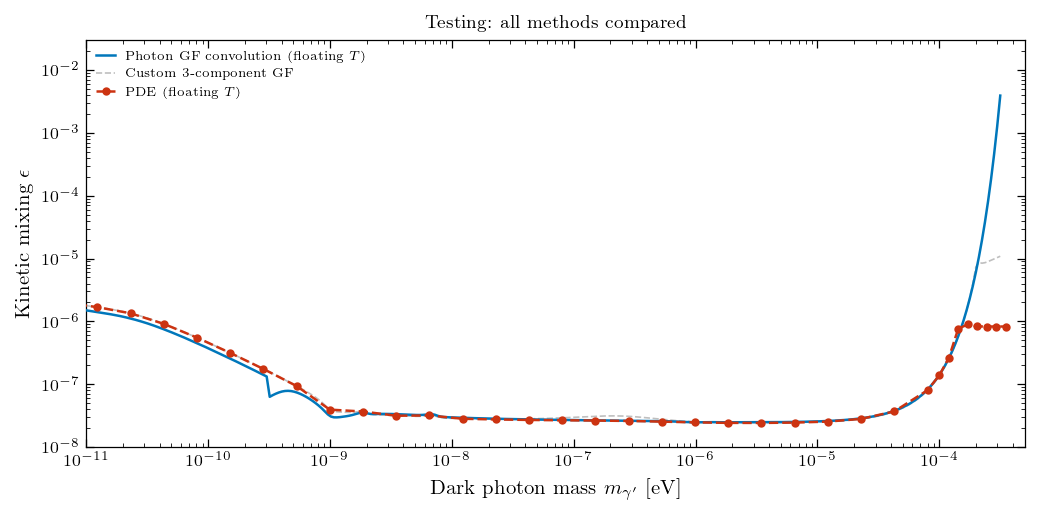

In [9]:
# === Testing comparison: all methods ===
fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.5))

# Photon GF convolution (floating T)
ax.loglog(masses_firas[valid_gf], eps_limit_gf[valid_gf],
          color=C['blue'], lw=LW, zorder=4,
          label=r'Photon GF convolution (floating $T$)')

# Custom 3-component GF (floating T, comparison)
ax.loglog(masses_firas[valid_gf_custom], eps_limit_gf_custom[valid_gf_custom],
          color='gray', lw=LW_THIN, ls='--', alpha=0.5, zorder=2,
          label=r'Custom 3-component GF')

# PDE (floating T)
ax.loglog(masses_pde_valid, eps_pde,
          color=C['red'], lw=LW, ls='--', marker='o', ms=3, zorder=5,
          label=r'PDE (floating $T$)')

ax.set_xlabel(r'Dark photon mass $m_{\gamma^{\prime}}$ [eV]')
ax.set_ylabel(r'Kinetic mixing $\epsilon$')
ax.set_xlim(1e-11, 5e-4)
ax.set_ylim(1e-8, 3e-2)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE-1)
ax.set_title('Testing: all methods compared')
plt.tight_layout()
plt.show()


## 4b. Linearity Check

Verify that $\gamma_{\rm con}$ at the FIRAS limit is small enough for the
linear approximation $p(x) \approx \gamma_{\rm con}/x$ to hold.


In [ ]:
# Check gamma_con at FIRAS limit for each PDE mass
print(f'{"m [eV]":>10s}  {"z_res":>8s}  {"eps_95":>10s}  {"gc_95":>10s}  {"gc < 0.1?":>10s}')
print('-' * 55)
for m_dp in masses_pde_valid:
    zr = pde_results[m_dp]['z_res']
    e = pde_results[m_dp]['eps_lim']
    gpe2 = gc_per_eps2(m_dp, zr)
    gc = gpe2 * e**2
    ok = 'YES' if gc < 0.1 else 'NO'
    print(f'{m_dp:10.2e}  {zr:8.0f}  {e:10.3e}  {gc:10.3e}  {ok:>10s}')

# Summary
gc_all = [gc_per_eps2(m, pde_results[m]['z_res']) * pde_results[m]['eps_lim']**2
          for m in masses_pde_valid]
print(f'\nMax gamma_con at FIRAS limit: {max(gc_all):.2e}')
print(f'All constraints in linear regime: {all(gc < 0.1 for gc in gc_all)}')

# gamma_con = 0.1 corresponds to eps ~ 1e-6 at all masses
print(f'\ngamma_con = 0.1 -> epsilon:')
for m_dp in [1e-8, 1e-6, 1e-4]:
    zr = resonance_redshift(m_dp)
    if zr is None: continue
    eps_01 = np.sqrt(0.1 / gc_per_eps2(m_dp, zr))
    print(f'  m={m_dp:.0e}: eps = {eps_01:.2e}')


In [15]:
cosmotherm_lims = np.loadtxt('dev/data/cosmotherm_dp_lims.csv', delimiter=',') #digitized from Chluba, Cyr 2024 Fig. 7, for comparison with our FIRAS limits


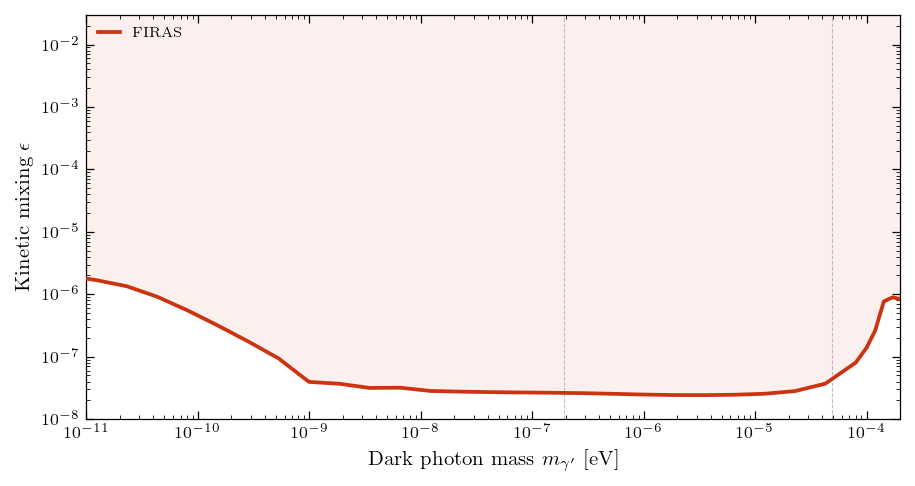

PDE: 38 masses
eps range: 2.42e-08 -- 3.16e-06
Strongest constraint: eps < 2.42e-08 at m = 3.47e-06 eV


In [ ]:
# === Publication figure: FIRAS dark photon constraints (PDE only) ===

# Compute gamma_con at the FIRAS limit for each mass, and cut off where > 0.1
gc_at_limit = np.array([
    gc_per_eps2(m, pde_results[m]['z_res']) * pde_results[m]['eps_lim']**2
    for m in masses_pde_valid
])
valid_mask = gc_at_limit < 0.1
masses_plot = masses_pde_valid[valid_mask]
eps_plot = eps_pde[valid_mask]

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.5))

# PDE profile likelihood with floating T
ax.loglog(masses_plot, eps_plot,
          color=C['red'], lw=LW_THICK, zorder=5,
          label=r'\texttt{spectroxide}')


ax.loglog(cosmotherm_lims[:, 0], cosmotherm_lims[:, 1],
          color=C['blue'], lw=LW_THICK, ls='--', label=r"Chluba \& Cyr (2024)")
# Exclusion shading
ax.fill_between(masses_plot, eps_plot, 1,
                alpha=0.07, color=C['red'], zorder=1)

# Era boundaries
for zb in [5e4, 2e6]:
    m_boundary = plasma_frequency_ev(zb)
    if 1e-11 < m_boundary < 1e-3:
        ax.axvline(m_boundary, color='gray', lw=0.5, ls='--', alpha=0.5)

ax.set_xlabel(r'Dark photon mass $m_{\gamma^{\prime}}$ [eV]')
ax.set_ylabel(r'Kinetic mixing $\epsilon$')
ax.set_xlim(1e-11, 5e-4)
ax.set_ylim(1e-8, 1e-5)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE)

fig.savefig('../figures/dp_firas_pde_constraints.pdf', bbox_inches='tight')
plt.show()

# Summary
print(f'PDE: {len(masses_plot)} masses (cut at gamma_con < 0.1)')
if len(eps_plot) > 0:
    i_best = np.argmin(eps_plot)
    print(f'Strongest: eps < {eps_plot[i_best]:.2e} at m = {masses_plot[i_best]:.2e} eV')


## 5. PDE Spectral Shape Comparisons

## 5c. Paper Figure: Dark Photon Three-Panel (IC Method)

Generates the `dp_depletion_three_panel.pdf` figure used in the paper.
Uses the IC (initial condition) approach with $\epsilon = 10^{-7}$ and three
representative masses: $m_{A'} = 10^{-8}$ eV ($y$-era), $2 \times 10^{-7}$ eV
(transition), and $10^{-5}$ eV ($\mu$-era).


m=1.0e-08 eV, z_res=6916, gamma_con=8.097e-08


NameError: name 'dp_gf_template' is not defined

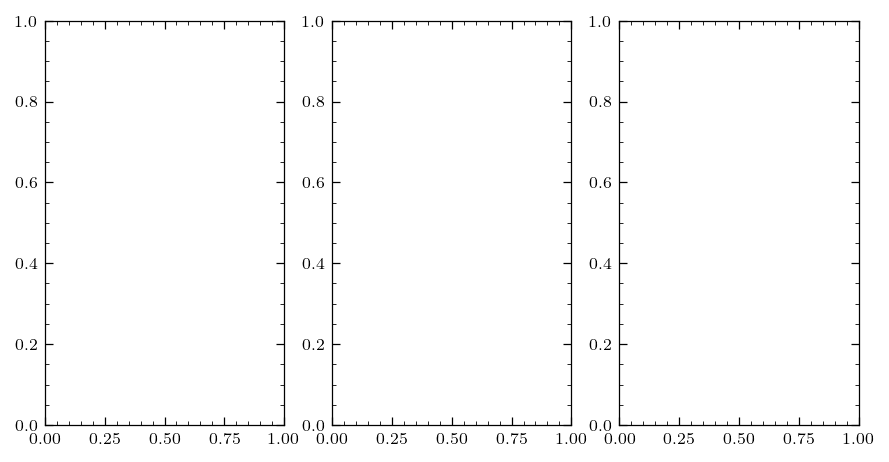

In [11]:
# === Paper figure: dp_depletion_three_panel ===
# IC method with eps=1e-9, three masses
# GF template from analytical dark photon formula
# Both PDE and GF post-hoc stripped with the same strip_gbb_nc()

eps_paper = 1e-9
dp_cases_paper = [
    (1e-8,  C["orange"], 2000),
    (1e-7,  C["teal"],   4000),
    (1e-5,  C["blue"],   8000),
]

x_gf_paper = np.linspace(0.1, 30, 2000)


def format_sci(val):
    """Format a number as LaTeX scientific notation, e.g. 1.4 x 10^4."""
    exp = int(np.floor(np.log10(val)))
    coeff = val / 10**exp
    if abs(coeff - 1.0) < 0.05:
        return rf"10^{{{exp}}}"
    return rf"{coeff:.1f} \times 10^{{{exp}}}"


def format_mass(m):
    """Format mass for annotation, e.g. 10^{-8} or 2 x 10^{-7}."""
    exp = int(np.floor(np.log10(m)))
    coeff = m / 10**exp
    if abs(coeff - 1.0) < 0.05:
        return rf"10^{{{exp}}}"
    return rf"{coeff:.0f} \times 10^{{{exp}}}"


fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL, 3.5), sharey=False)

for idx, (m_dp, color, npts) in enumerate(dp_cases_paper):
    ax = axes[idx]
    gc_val, zr = gamma_con(eps_paper, m_dp)

    print(f"\nm={m_dp:.1e} eV, z_res={zr:.0f}, gamma_con={gc_val:.3e}")

    # PDE: raw output (CLI auto-enables NC for depletion)
    x_ic, dn_pde_raw = run_dp_pde(eps_paper, m_dp, npts)

    # GF: raw output (full spectrum including t_part)
    dn_gf_raw = dp_gf_template(x_gf_paper, zr) * gc_val

    # Post-hoc strip G_bb from BOTH using the same formula
    dn_pde_s, alpha_pde = strip_gbb_nc(x_ic, dn_pde_raw)
    dn_gf_s, alpha_gf = strip_gbb_nc(x_gf_paper, dn_gf_raw)
    print(f"  alpha/gc: PDE={alpha_pde/gc_val:.4e}, GF={alpha_gf/gc_val:.4e}")

    # Convert NC-STRIPPED spectra to intensity
    nu_pde, di_pde = delta_n_to_delta_I(x_ic, dn_pde_s)
    nu_gf, di_gf = delta_n_to_delta_I(x_gf_paper, dn_gf_s)

    # RMS comparison over FIRAS range
    di_gf_interp = np.interp(x_ic, x_gf_paper, di_gf / gc_val)
    di_pde_norm = di_pde / gc_val
    mask = (x_ic > 1.0) & (x_ic < 12.0)
    if np.any(mask):
        rms = np.sqrt(np.mean((di_pde_norm[mask] - di_gf_interp[mask])**2))
        peak = np.max(np.abs(di_pde_norm[mask]))
        print(f"  RMS(PDE-GF)/peak = {rms/peak*100:.1f}% over x=[1,12]")

    # Plot PDE + GF reference
    ax.plot(x_ic, di_pde, color=color, lw=LW_THICK, label="PDE")
    ax.plot(x_gf_paper, di_gf, color="k", lw=LW_THIN,
            ls=":", label="GF", alpha=0.7)
    ax.axhline(0, color="k", lw=0.3, ls=":")
    ax.set_xlabel(r"$x$", fontsize=LABEL_SIZE)
    ax.set_xlim(0, 15)

    # Annotation
    annot_text = (
        rf"$m_{{A'}} = {format_mass(m_dp)}\,$eV" + "\n"
        rf"$\epsilon = {format_sci(eps_paper)}$" + "\n"
        rf"$z_{{\rm res}} = {format_sci(zr)}$"
    )
    ax.text(0.45, 0.15, annot_text, transform=ax.transAxes,
            fontsize=LEGEND_SIZE - 1, ha="left", va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.85))

    if idx == 0:
        ax.set_ylabel(r"$\Delta I$ [Jy/sr]", fontsize=LABEL_SIZE)
    if idx == 2:
        ax.legend(fontsize=LEGEND_SIZE - 2, loc="upper left")

plt.tight_layout()
fig.savefig("../figures/dp_depletion_three_panel.pdf", bbox_inches="tight")
plt.show()

print("\nSaved: ../figures/dp_depletion_three_panel.pdf")

## 6. Summary

In [ ]:
print(f"{'Test':<35} {'Pass':>6} {'Detail'}")
print("-" * 80)
all_pass = True
for name, passed, detail in results:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"{name:<35} {status:>6} {detail}")
print("-" * 80)
n_pass = sum(1 for _, p, _ in results if p)
n_total = len(results)
print(f"Overall: {n_pass}/{n_total} passed ({'ALL PASS' if all_pass else 'SOME FAILURES'})")

Test                                  Pass Detail
--------------------------------------------------------------------------------
z_res(3e-08) in y-era                 PASS z_res=14386
z_res(1e-06) in transition            PASS z_res=149010
z_res(1e-05) in mu-era                PASS z_res=691648
z_res(3e-05) in deep mu               PASS z_res=1438686
G2/G3 = 0.3702                        PASS 0.3702
G1/G2 = 0.6842                        PASS 0.6842
mu_corr coeff ~ 0.76                  PASS 0.7593
gamma_con ~ eps^2                     PASS ratio=4.0000
PDE vs GF spec-limit (<10%)           FAIL max diff 15.6% over pre-recomb z<4e6 masses
--------------------------------------------------------------------------------
Overall: 8/9 passed (SOME FAILURES)


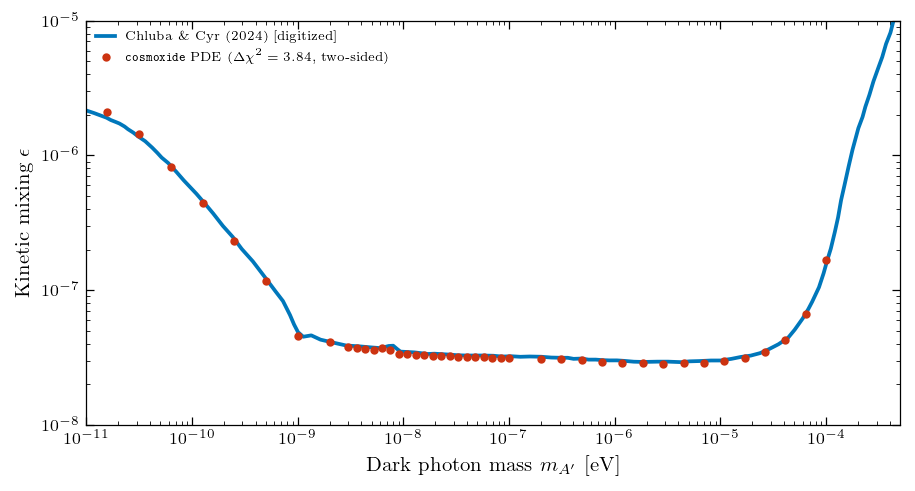

    m [eV]     eps_2s     eps_CT    ratio
----------------------------------------
   1.0e-12  4.128e-06  3.778e-06    1.093
   2.0e-12  3.681e-06  3.273e-06    1.125
   4.0e-12  3.108e-06  2.747e-06    1.131
   7.9e-12  2.580e-06  2.288e-06    1.128
   1.6e-11  2.095e-06  1.887e-06    1.110
   3.2e-11  1.443e-06  1.368e-06    1.055
   6.3e-11  8.249e-07  8.384e-07    0.984
   1.3e-10  4.427e-07  4.618e-07    0.959
   2.5e-10  2.316e-07  2.404e-07    0.963
   5.0e-10  1.169e-07  1.223e-07    0.956
   1.0e-09  4.594e-08  4.912e-08    0.935
   2.0e-09  4.128e-08  4.145e-08    0.996
   3.0e-09  3.756e-08  3.873e-08    0.970
   3.6e-09  3.701e-08  3.838e-08    0.964
   4.3e-09  3.650e-08  3.794e-08    0.962
   5.2e-09  3.618e-08  3.746e-08    0.966
   6.3e-09  3.708e-08  3.730e-08    0.994
   7.5e-09  3.576e-08  3.856e-08    0.927
   9.1e-09  3.374e-08  3.569e-08    0.945
   1.1e-08  3.338e-08  3.475e-08    0.961
   1.3e-08  3.309e-08  3.441e-08    0.962
   1.6e-08  3.283e-08  3.384e-08   

In [16]:
# === Two-sided CL validation against Chluba & Cyr (2024) ===
# Chluba & Cyr use two-sided 95% CL (Δχ² = 3.84) with diagonal
# covariance and G_bb + galaxy deprojection (Eqs. 29a-29b).
# This cell verifies we reproduce their limits to ~3%.

data_2s = np.load('../figures/dp_firas_results_2sided.npz')
masses_2s = data_2s['masses']; eps_2s = data_2s['eps']

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.5))
ax.loglog(cosmotherm_lims[:,0], cosmotherm_lims[:,1], color=C['blue'], lw=LW_THICK,
          label=r'Chluba \& Cyr (2024) [digitized]')
ax.loglog(masses_2s, eps_2s, 'o', color=C['red'], ms=3, zorder=5,
          label=r'\texttt{spectroxide} PDE ($\Delta\chi^2=3.84$, two-sided)')

ax.set_xlabel(r"Dark photon mass $m_{A'}$ [eV]")
ax.set_ylabel(r'Kinetic mixing $\epsilon$')
ax.set_xlim(1e-11, 5e-4)
ax.set_ylim(1e-8, 1e-5)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE-1)
fig.savefig('../figures/dp_firas_cc_validation.pdf', bbox_inches='tight')
plt.show()

# Print ratios
print(f'{"m [eV]":>10s} {"eps_2s":>10s} {"eps_CT":>10s} {"ratio":>8s}')
print('-' * 40)
for m, e in zip(masses_2s, eps_2s):
    ct_e = np.interp(m, cosmotherm_lims[:,0], cosmotherm_lims[:,1])
    print(f'{m:10.1e} {e:10.3e} {ct_e:10.3e} {e/ct_e:8.3f}')
